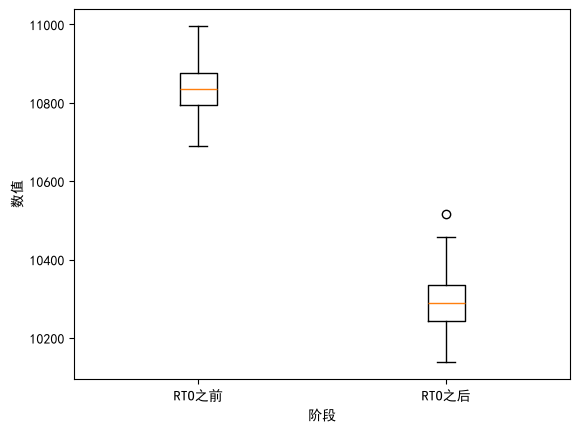

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(seed=42)
before_RTO = rng.normal(loc=10835, scale=75, size=100)
after_RTO = rng.normal(loc=10298, scale=75, size=100)

RTO_Data = pd.DataFrame({'before': before_RTO, 'after': after_RTO})
RTO_Data.to_csv('RTO_Data.csv', index=False, encoding='utf-8-sig')

Data = pd.read_csv('RTO_Data.csv')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 将字体设置为黑体
plt.rcParams['axes.unicode_minus'] = False    # 依然要保留这句，防止负号显示异常
plt.boxplot(Data)
plt.ylabel('数值')
plt.xlabel('阶段')
plt.xticks([1, 2], ['RTO之前','RTO之后'])
plt.show()

          before         after
0   10857.853781  10279.091872
1   10757.001192  10362.961415
2   10891.283840  10280.186801
3   10905.542354  10334.875778
4   10688.672361  10251.319116
..           ...           ...
95  10726.466565  10253.263649
96  10735.797529  10330.166340
97  10760.206488  10278.269744
98  10864.983067  10297.743907
99  10767.089071  10289.827855

[100 rows x 2 columns]
         阶段            数值
0    before  10857.853781
1    before  10757.001192
2    before  10891.283840
3    before  10905.542354
4    before  10688.672361
..      ...           ...
195   after  10253.263649
196   after  10330.166340
197   after  10278.269744
198   after  10297.743907
199   after  10289.827855

[200 rows x 2 columns]
                0.25          0.50          0.75
阶段                                              
after   10260.642259  10291.514270  10322.667094
before  10794.207387  10834.838486  10875.126534
0     10857.853781
1     10757.001192
2     10891.283840
3     10905.542

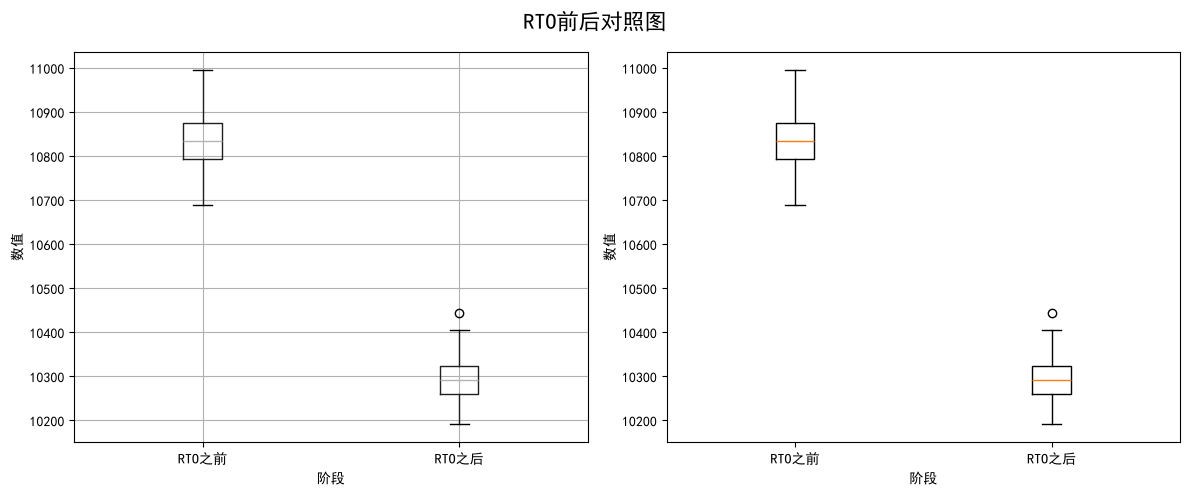

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(seed=42)
before_RTO = rng.normal(loc=10835, scale=75, size=100)
after_RTO = rng.normal(loc=10298, scale=50, size=100)

RTO_Data = pd.DataFrame({'before': before_RTO, 'after': after_RTO})
print(RTO_Data)
RTO_Data.to_csv('RTO_Data.csv', index=False, encoding='utf-8-sig')

Data = pd.read_csv('RTO_Data.csv').melt(var_name='阶段', value_name='数值')
print(Data)

print(Data.groupby('阶段')) #内存里在分组，但是没有真分
result = Data.groupby('阶段')['数值'].quantile([0.25, 0.5, 0.75]).unstack() #按阶段分组，然后选择”数据“这一列进行分位数计算
print(result)

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) #不用全局画图，用精确画图
# axes 变量里存的是由多个“坐标系对象（Axes）”组成的 NumPy 数组（列表）

from pandas.api.types import CategoricalDtype #法1
order = ['before', 'after'] # 你希望的顺序
Data['阶段'] = Data['阶段'].astype(CategoricalDtype(order, ordered=True))
Data.boxplot(column='数值', by='阶段', ax=axes[0])
axes[0].set_title('')
plt.suptitle('')
axes[0].set_ylabel('数值')
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['RTO之前', 'RTO之后'])

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
data_before = Data[Data['阶段'] == 'before']['数值']
data_after = Data[Data['阶段'] == 'after']['数值']
print(data_before)
plot_data = [data_before, data_after]
axes[1].boxplot(plot_data)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['RTO之前', 'RTO之后']) # 法2
axes[1].set_ylabel('数值')
plt.xlabel('阶段')
fig.suptitle('RTO前后对照图', fontsize=16)
plt.tight_layout() # 自动调整间距
plt.show()

In [22]:
print(result)
median_diff = result.loc['before', 0.5] - result.loc['after', 0.5]
print(f"中位数降幅为：{median_diff}")

                0.25          0.50          0.75
阶段                                              
after   10260.642259  10291.514270  10322.667094
before  10794.207387  10834.838486  10875.126534
中位数降幅为：543.3242163590348


1、为什么用中位数而不是均值？
提示：看看你的图，两边的箱体外面都有几个“小圆圈”（那是异常值/离群点）。均值很容易受这几个极端值影响被拉高或拉低，而中位数（箱体中间的横线）是稳稳代表大多数水平的。

2、四分位区间收窄说明什么？
提示：看看你图的右边（RTO之后），箱体是不是明显比左边短？箱子短，说明数据更集中，波动更小。这意味着 RTO 不仅降低了能耗，还提高了生产的稳定性。

3、如果负荷分布不同，直接比较是否公平？
提示：如果 RTO 之前都是在100%满负荷生产（电耗天然高），RTO 之后都是50%低负荷（电耗天然低），这样直接比就是不公平的。你需要按“高/中/低负荷”进行分组（这正是你刚刚学的 groupby 的用武之地！），在同一负荷下比较才公平。